# Nama: Moh Syuril Iswan
# NIM: 4222301069
# Kelas:A MALAM


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [22]:
DATASET_PATH = "TrashType_Image_Dataset"

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32

print("Dataset ditemukan :", os.path.exists(DATASET_PATH))

Dataset ditemukan : True


In [23]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    width_shift_range=0.2,

    height_shift_range=0.2,

    validation_split=0.15

)

In [24]:
train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True

)

validation_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False

)

Found 2150 images belonging to 6 classes.
Found 377 images belonging to 6 classes.


In [25]:
print("Class :")
print(train_generator.class_indices)

print()

print("Jumlah Data Training :",
      train_generator.samples)

print("Jumlah Data Validation :",
      validation_generator.samples)

Class :
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Jumlah Data Training : 2150
Jumlah Data Validation : 377


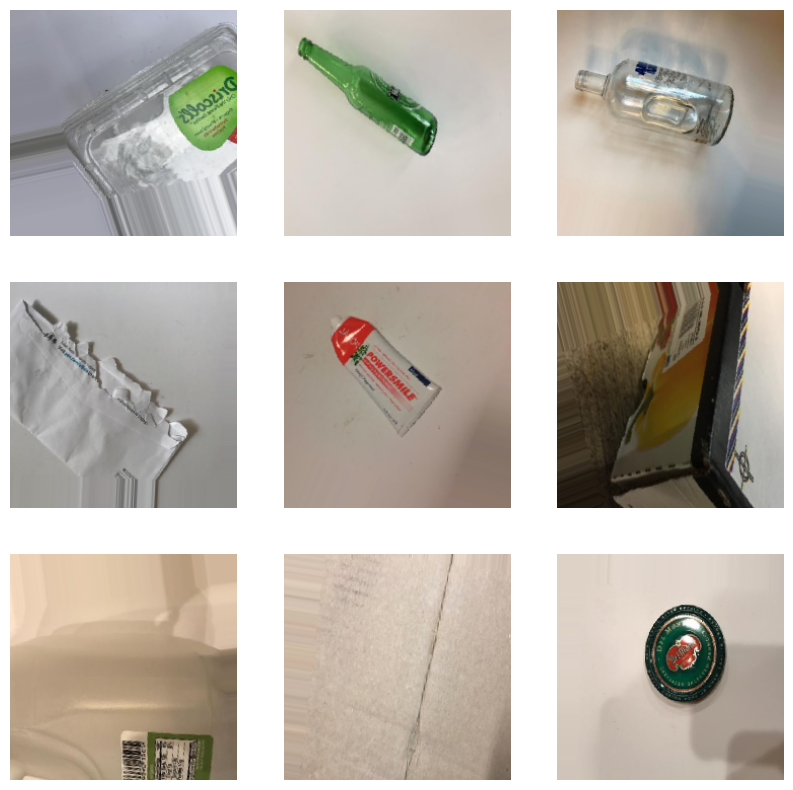

In [26]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [27]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

In [28]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

output = Dense(

    train_generator.num_classes,

    activation='softmax'

)(x)

model = Model(

    inputs=base_model.input,

    outputs=output

)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

output = Dense(

    train_generator.num_classes,

    activation='softmax'

)(x)

model = Model(

    inputs=base_model.input,

    outputs=output

)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [31]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True

)

In [32]:
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=2,

    verbose=1

)

In [33]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20,

    callbacks=[early_stop, reduce_lr]

)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.2205 - loss: 2.0780 - val_accuracy: 0.3581 - val_loss: 1.6003 - learning_rate: 1.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.3084 - loss: 1.8329 - val_accuracy: 0.4775 - val_loss: 1.4316 - learning_rate: 1.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 621ms/step - accuracy: 0.3981 - loss: 1.6347 - val_accuracy: 0.5199 - val_loss: 1.2665 - learning_rate: 1.0000e-04
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 582ms/step - accuracy: 0.4395 - loss: 1.4886 - val_accuracy: 0.5862 - val_loss: 1.1363 - learning_rate: 1.0000e-04
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 38s 556ms/step - accuracy: 0.4744 - loss: 1.3961 - val_accuracy: 0.6074 - val_loss: 1.0965 - learning_rate: 1.0000e-04
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 38s 564ms/step - accuracy: 0.4972 - loss: 1.3042 - val_accuracy: 0.6313 - val_loss: 1.0067 - learning_rate: 1.0000e-04
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 38s 564ms/step - accuracy:

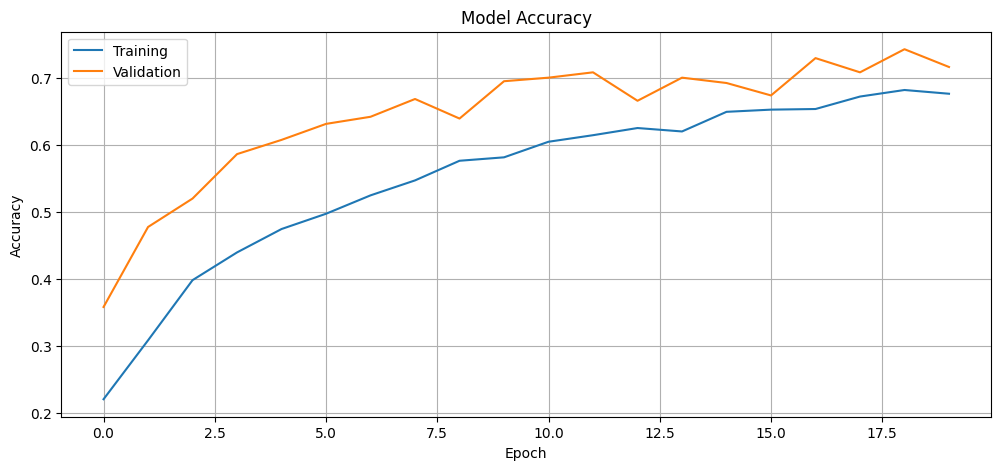

In [36]:
plt.figure(figsize=(12,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([

    "Training",

    "Validation"

])

plt.grid()

plt.show()

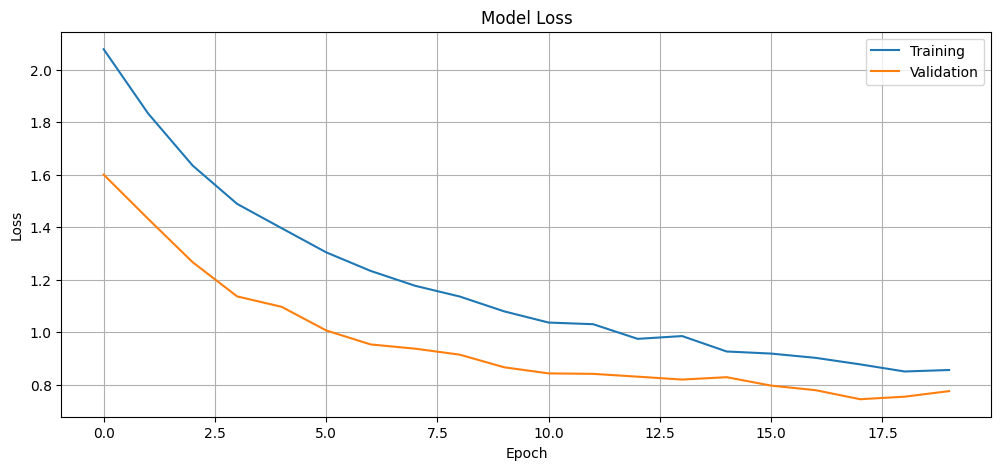

In [37]:
plt.figure(figsize=(12,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([

    "Training",

    "Validation"

])

plt.grid()

plt.show()

In [38]:
loss, accuracy = model.evaluate(

    validation_generator

)

print("Accuracy :", accuracy)

print("Loss :", loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 572ms/step - accuracy: 0.7268 - loss: 0.7680
Accuracy : 0.7267904281616211
Loss : 0.7680256962776184


In [39]:
train_acc = history.history["accuracy"][-1]

val_acc = history.history["val_accuracy"][-1]

gap = train_acc - val_acc

print("Training Accuracy :", train_acc)

print("Validation Accuracy :", val_acc)

print("Selisih :", gap)

if gap > 0.10:

    print("Terjadi OVERFITTING")

else:

    print("Tidak terjadi overfitting")

Training Accuracy : 0.6762790679931641
Validation Accuracy : 0.7161803841590881
Selisih : -0.03990131616592407
Tidak terjadi overfitting


In [40]:
validation_generator.reset()

predictions = model.predict(

    validation_generator

)

y_pred = np.argmax(

    predictions,

    axis=1

)

y_true = validation_generator.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 724ms/step


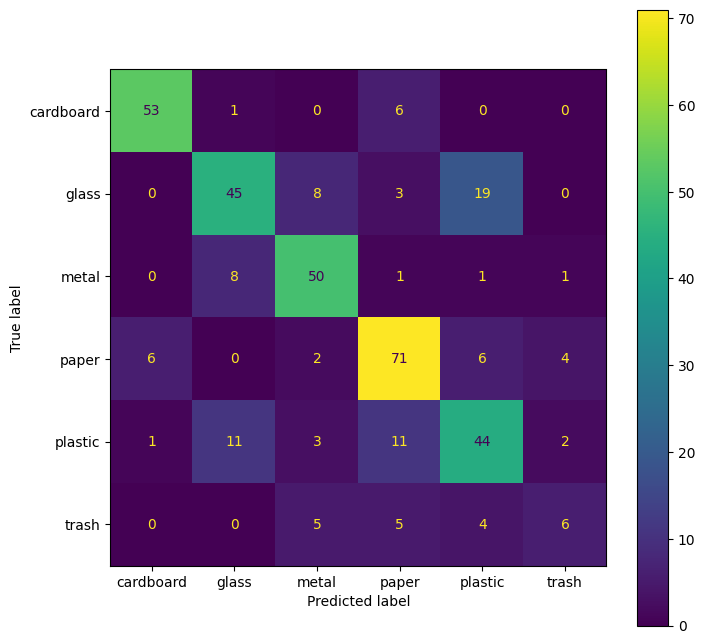

In [41]:
cm = confusion_matrix(

    y_true,

    y_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=list(
        train_generator.class_indices.keys()
    )

)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.show()

In [42]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=list(
            train_generator.class_indices.keys()
        )

    )

)

              precision    recall  f1-score   support

   cardboard       0.88      0.88      0.88        60
       glass       0.69      0.60      0.64        75
       metal       0.74      0.82      0.78        61
       paper       0.73      0.80      0.76        89
     plastic       0.59      0.61      0.60        72
       trash       0.46      0.30      0.36        20

    accuracy                           0.71       377
   macro avg       0.68      0.67      0.67       377
weighted avg       0.71      0.71      0.71       377



Pada praktikum ini dilakukan klasifikasi citra menggunakan metode Transfer Learning MobileNetV2 pada dataset Trash Type Image Dataset. Tahapan yang dilakukan meliputi preprocessing data, augmentasi citra, pelatihan model, dan evaluasi menggunakan confusion matrix serta classification report. Berdasarkan hasil pelatihan, nilai training accuracy dan validation accuracy memiliki selisih yang kecil sehingga tidak ditemukan indikasi overfitting. Penggunaan Data Augmentation, Dropout, EarlyStopping, dan ReduceLROnPlateau membantu meningkatkan kemampuan generalisasi model sehingga model mampu mengklasifikasikan berbagai jenis sampah dengan baik.